## Задача 1. Оценить месячный retention в оформление заказа с помощью когортного анализа.

### Импорт библиотек

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Загрузка данных

In [138]:
customers = pd.read_csv('olist_customers_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')

### Объединение таблиц

In [139]:
df = orders.merge(customers, on='customer_id', how='left')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


### Преобразование дат

In [140]:
df['order_purchase'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_purchase'].dtype

dtype('<M8[ns]')

### Фильтр доставленных заказов

In [141]:
df_delivered = df[df['order_status'] == 'delivered'].copy()
print(f"Доставленных заказов: {len(df_delivered)}")
df_delivered.head()

Доставленных заказов: 96478


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_purchase
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02-13 21:18:39


### Создание месяца заказа

In [142]:
df_delivered['order_month'] = df_delivered['order_purchase'].dt.to_period('M')
df_delivered[['order_id', 'order_purchase', 'order_month']].head(10)

,order_id,order_purchase,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05,2017-07
7,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30,2017-05
8,76c6e866289321a7c93b82b54852dc33,2017-01-23 18:29:09,2017-01
9,e69bfb5eb88e0ed6a785585b27e16dbf,2017-07-29 11:55:02,2017-07
10,e6ce16cb79ec1d90b1da9085a6118aeb,2017-05-16 19:41:10,2017-05


### Нахождение первого заказа для каждого покупателя

In [143]:
first_purchase = df_delivered.groupby('customer_unique_id')['order_month'].min().reset_index()
first_purchase.columns = ['customer_unique_id', 'cohort_month']
first_purchase.head(10)

,customer_unique_id,cohort_month
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05
2,0000f46a3911fa3c0805444483337064,2017-03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10
4,0004aac84e0df4da2b147fca70cf8255,2017-11
5,0004bd2a26a76fe21f786e4fbd80607f,2018-04
6,00050ab1314c0e55a6ca13cf7181fecf,2018-04
7,00053a61a98854899e70ed204dd4bafe,2018-02
8,0005e1862207bf6ccc02e4228effd9a0,2017-03
9,0005ef4cd20d2893f0d9fbd94d3c0d97,2018-03


### Присоединение когортного месяца

In [144]:
df_delivered = df_delivered.merge(first_purchase, on='customer_unique_id', how='left')
df_delivered[['customer_unique_id', 'order_month', 'cohort_month']].head(10)

,customer_unique_id,order_month,cohort_month
0,7c396fd4830fd04220f754e42b4e5bff,2017-10,2017-09
1,af07308b275d755c9edb36a90c618231,2018-07,2018-07
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08
3,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02
5,80bb27c7c16e8f973207a5086ab329e2,2017-07,2017-07
6,932afa1e708222e5821dac9cd5db4cae,2017-05,2017-05
7,39382392765b6dc74812866ee5ee92a7,2017-01,2017-01
8,299905e3934e9e181bfb2e164dd4b4f8,2017-07,2017-07
9,f2a85dec752b8517b5e58a06ff3cd937,2017-05,2017-05


### Расчет номера месяца

In [145]:
df_delivered['month_number'] = (df_delivered['order_month'].dt.year - df_delivered['cohort_month'].dt.year) * 12 \
                               + (df_delivered['order_month'].dt.month - df_delivered['cohort_month'].dt.month)

print(f"Month number от {df_delivered['month_number'].min()} до {df_delivered['month_number'].max()}")
df_delivered[df_delivered['month_number'] <= 3].head(20)

Month number от 0 до 20


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_purchase,order_month,cohort_month,month_number
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10-02 10:56:33,2017-10,2017-09,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07-24 20:41:37,2018-07,2018-07,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08-08 08:38:49,2018-08,2018-08,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11-18 19:28:06,2017-11,2017-11,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02-13 21:18:39,2018-02,2018-02,0
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,2017-07-09 21:57:05,2017-07,2017-07,0
6,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,932afa1e708222e5821dac9cd5db4cae,26525,nilopolis,RJ,2017-05-16 13:10:30,2017-05,2017-05,0
7,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,39382392765b6dc74812866ee5ee92a7,99655,faxinalzinho,RS,2017-01-23 18:29:09,2017-01,2017-01,0
8,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,299905e3934e9e181bfb2e164dd4b4f8,18075,sorocaba,SP,2017-07-29 11:55:02,2017-07,2017-07,0
9,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07 00:00:00,f2a85dec752b8517b5e58a06ff3cd937,20780,rio de janeiro,RJ,2017-05-16 19:41:10,2017-05,2017-05,0


### Группировка для когортной таблицы

In [146]:
cohort_data = df_delivered.groupby(['cohort_month', 'month_number'])['customer_unique_id'].nunique().reset_index()
cohort_data.columns = ['cohort_month', 'month_number', 'users_count']
cohort_data.head(10)

,cohort_month,month_number,users_count
0,2016-09,0,1
1,2016-10,0,262
2,2016-10,6,1
3,2016-10,9,1
4,2016-10,11,1
5,2016-10,13,1
6,2016-10,15,1
7,2016-10,17,1
8,2016-10,19,2
9,2016-10,20,2


### Расчет размера когорт

In [147]:
cohort_size = cohort_data[cohort_data['month_number'] == 0][['cohort_month', 'users_count']].rename(
    columns={'users_count': 'cohort_size'}
)
cohort_size.head(10)

,cohort_month,cohort_size
0,2016-09,1
1,2016-10,262
10,2016-12,1
12,2017-01,717
30,2017-02,1628
48,2017-03,2503
66,2017-04,2256
83,2017-05,3451
99,2017-06,3037
114,2017-07,3752


### Финальная когортная таблица

In [148]:
cohort_data = cohort_data.merge(cohort_size, on='cohort_month', how='left')
cohort_data['retention'] = (cohort_data['users_count'] / cohort_data['cohort_size']) * 100

retention_pivot = cohort_data.pivot(index='cohort_month', columns='month_number', values='retention')
retention_pivot = retention_pivot.fillna(0)


retention_pivot.round(2)

month_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2016-10,100.0,0.00,0.00,0.00,0.00,0.00,0.38,0.00,0.00,0.38,0.00,0.38,0.00,0.38,0.00,0.38,0.00,0.38,0.76,0.76
2016-12,100.0,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-01,100.0,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,0.00,0.42,0.14,0.70,0.42,0.14,0.14,0.28,0.42,0.14,0.00
2017-02,100.0,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,0.12,0.31,0.12,0.18,0.12,0.06,0.06,0.18,0.00,0.00
2017-03,100.0,0.44,0.36,0.40,0.36,0.16,0.16,0.32,0.32,0.08,0.36,0.12,0.20,0.12,0.16,0.24,0.08,0.12,0.00,0.00
2017-04,100.0,0.62,0.22,0.18,0.27,0.27,0.35,0.31,0.31,0.18,0.27,0.09,0.04,0.04,0.09,0.09,0.13,0.00,0.00,0.00
2017-05,100.0,0.46,0.46,0.29,0.29,0.32,0.41,0.14,0.26,0.26,0.26,0.35,0.23,0.03,0.17,0.20,0.00,0.00,0.00,0.00
2017-06,100.0,0.49,0.40,0.43,0.30,0.40,0.36,0.23,0.13,0.20,0.30,0.36,0.16,0.16,0.23,0.00,0.00,0.00,0.00,0.00


### Медианный retention 1-го месяца

In [149]:
if 1 in retention_pivot.columns:
    print(round(retention_pivot[1][retention_pivot[1] > 0].median(), 2))

0.51


### Лучшая когорта на 3-й месяц

In [150]:
if 3 in retention_pivot.columns:
    retention_month3 = retention_pivot[3][retention_pivot[3] > 0]
    best_cohort = retention_month3.idxmax()
    print(f"Лучшая когорта на 3-й месяц: {best_cohort}")
    print(f"Retention: {retention_month3.max():.2f}%")

Лучшая когорта на 3-й месяц: 2017-06
Retention: 0.43%


### Тепловая карта

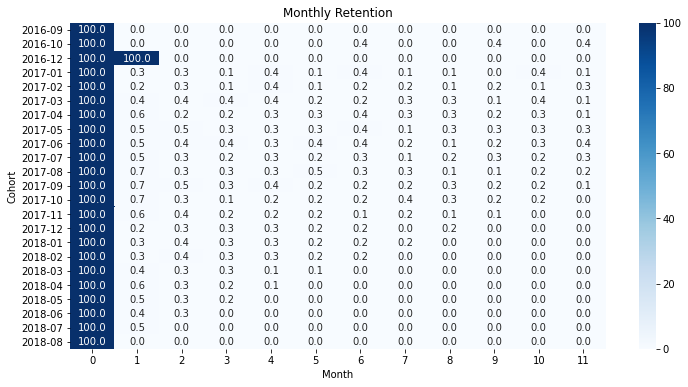

In [151]:
plt.figure(figsize=(12, 6))
plot_data = retention_pivot.iloc[:, :12]
sns.heatmap(plot_data, annot=True, fmt='.1f', cmap='Blues')
plt.title('Monthly Retention')
plt.xlabel('Month')
plt.ylabel('Cohort')
plt.show()

## Задача 2. Определить, существует ли product/market fit у маркетплейса.

### Средний retention по всем когортам для разных месяцев

In [152]:
avg_retention = {}
for month in [1, 2, 3, 6, 12]:
    if month in retention_pivot.columns:
        month_data = retention_pivot[month][retention_pivot[month] > 0]
        if len(month_data) > 0:
            avg_retention[month] = month_data.mean()
            print(f"Month {month}: средний retention = {avg_retention[month]:.1f}%")

Month 1: средний retention = 5.5%
Month 2: средний retention = 0.3%
Month 3: средний retention = 0.3%
Month 6: средний retention = 0.3%
Month 12: средний retention = 0.2%


### Доля когорт с положительным retention на 3-й месяц

In [153]:
if 3 in retention_pivot.columns:
    positive_at_3 = (retention_pivot[3] > 0).sum()
    total_cohorts = len(retention_pivot[3].dropna())
    pct_positive = (positive_at_3 / total_cohorts) * 100
    print(f"\nКогорт с retention > 0 на 3-й месяц: {positive_at_3} из {total_cohorts} ({pct_positive:.1f}%)")



Когорт с retention > 0 на 3-й месяц: 17 из 23 (73.9%)


### Медианный retention на 3-й месяц

In [154]:
if 3 in retention_pivot.columns:
    median_3 = retention_pivot[3][retention_pivot[3] > 0].median()
    print(f"Медианный retention на 3-й месяц: {median_3:.1f}%")

Медианный retention на 3-й месяц: 0.3%


### Визуализация

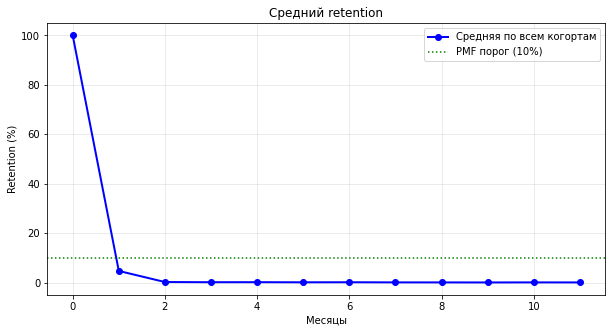

In [155]:
plt.figure(figsize=(10, 5))

# Усредняем по всем когортам
avg_retention_curve = retention_pivot.mean(axis=0)[:12]

plt.plot(avg_retention_curve.index, avg_retention_curve.values, 'b-o', label='Средняя по всем когортам', linewidth=2)

plt.axhline(y=10, color='g', linestyle=':', label='PMF порог (10%)')
plt.xlabel('Месяцы')
plt.ylabel('Retention (%)')
plt.title('Средний retention')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Вывод
Product/Market Fit не достигнут. Это утверждение основано на результатах когортного анализа retention: уже на второй месяц после первой покупки retention падает до 0,3% и остается на этом критически низком уровне в течение всего наблюдаемого периода. Клиенты совершают разовую покупку и больше не возвращаются, что говорит о том, что продукт не решает их долгосрочную потребность или не оправдывает ожидания.

### Фокус в ближайшее время
1) Провести опросы клиентов, которые не вернулись за повторной покупкой  
2) Проанализировать отзывы и оценки на товары и доставку  
3) Изучить поведение пользователей на сайте/в приложении  
4) Запустить программу лояльности с накоплением баллов  
5) Добавить товары с высокой частотой покупок  
6) Сократить сроки доставки  
7) Снизить стоимость доставки или сделать ее бесплатной от определенной суммы  

## Задача 3. Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

### Основные метрики:
GMV (Валовая стоимость товаров) — Рост объёма продаж  
MAU (Месячная активная аудитория)	— Объём аудитории, которой продукт доставляет ценность  
Conversion Rate (Конверсия) — Заинтересованность новых клиентов  
Retention Rate (Удержание пользователей) — Вовлеченность клиентов в продолжение использования  
LTV	(Жизненная ценность клиента) — Денежное выражение вовлеченности клиента  

### Визуализация метрик

### GMV

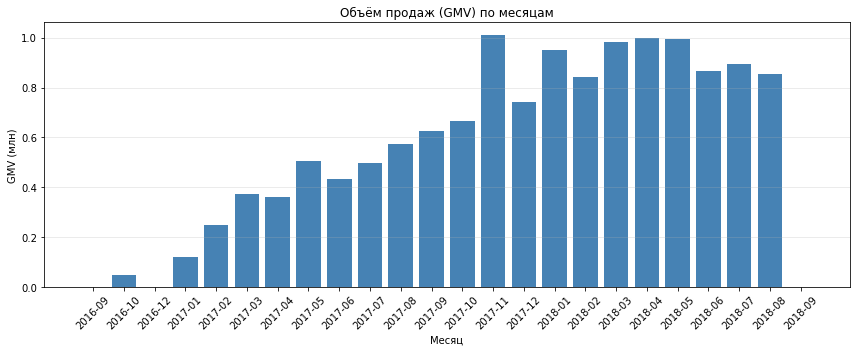

Общий GMV: 13.59 млн


In [156]:
sales = orders.merge(order_items, on='order_id', how='inner')

sales['order_purchase'] = pd.to_datetime(sales['order_purchase_timestamp'])
sales['order_month'] = sales['order_purchase'].dt.to_period('M')

gmv = sales.groupby('order_month', as_index=False)['price'].sum()
gmv['order_month'] = gmv['order_month'].astype(str)

plt.figure(figsize=(12, 5))
plt.bar(gmv['order_month'], gmv['price'] / 1e6, color='steelblue')
plt.xlabel('Месяц')
plt.ylabel('GMV (млн)')
plt.title('Объём продаж (GMV) по месяцам')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Общий GMV: {gmv['price'].sum() / 1e6:.2f} млн")

### MAU

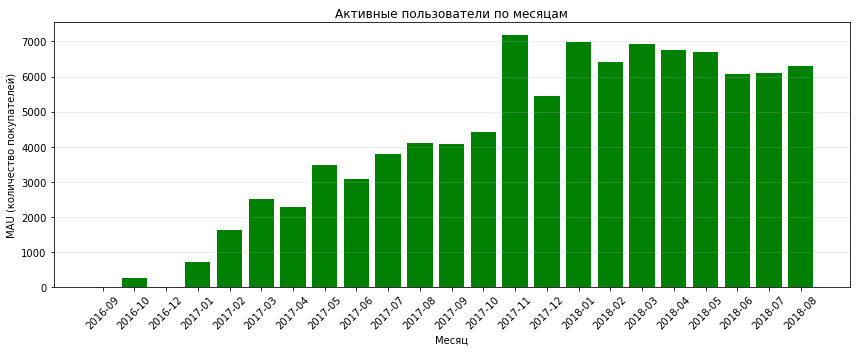

Средний MAU: 4139
Максимальный MAU: 7183


In [157]:
active_users = df_delivered.groupby('order_month')['customer_unique_id'].nunique().reset_index()
active_users['order_month'] = active_users['order_month'].astype(str)

plt.figure(figsize=(12, 5))
plt.bar(active_users['order_month'], active_users['customer_unique_id'], color='green')
plt.xlabel('Месяц')
plt.ylabel('MAU (количество покупателей)')
plt.title('Активные пользователи по месяцам')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Средний MAU: {active_users['customer_unique_id'].mean():.0f}")
print(f"Максимальный MAU: {active_users['customer_unique_id'].max():.0f}")

### Retention Rate

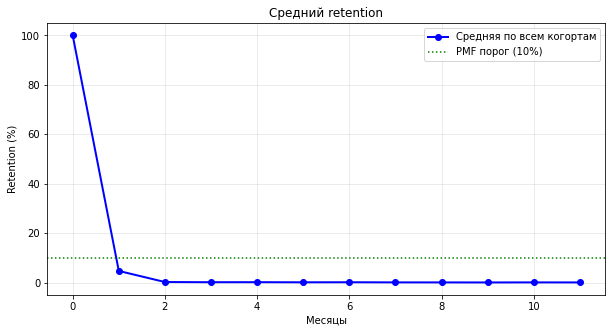

In [158]:
plt.figure(figsize=(10, 5))

avg_retention_curve = retention_pivot.mean(axis=0)[:12]

plt.plot(avg_retention_curve.index, avg_retention_curve.values, 'b-o', label='Средняя по всем когортам', linewidth=2)

plt.axhline(y=10, color='g', linestyle=':', label='PMF порог (10%)')
plt.xlabel('Месяцы')
plt.ylabel('Retention (%)')
plt.title('Средний retention')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### LTV

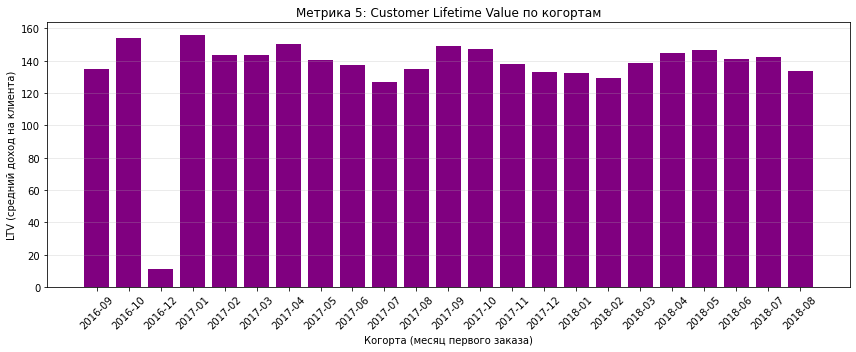

Средний чек: 137.75
Среднее количество заказов на клиента: 1.03
Средний LTV: 142.36


In [159]:
avg_order_value = sales.groupby('order_id')['price'].sum().mean()

avg_orders_per_customer = df_delivered.groupby('customer_unique_id')['order_id'].nunique().mean()

ltv = avg_order_value * avg_orders_per_customer


new_customers = first_order_month.copy()
new_customers['cohort_month'] = new_customers['cohort_month'].astype(str)
new_customers_count = new_customers.groupby('cohort_month').size().reset_index(name='new_customers')

# Доход от новых клиентов в первый месяц
revenue_from_new = df_delivered[df_delivered['month_number'] == 0].merge(
    sales[['order_id', 'price']], on='order_id', how='left'
)
revenue_new_monthly = revenue_from_new.groupby('cohort_month')['price'].sum().reset_index()
revenue_new_monthly['cohort_month'] = revenue_new_monthly['cohort_month'].astype(str)

# LTV по когортам (доход / количество новых клиентов)
ltv_by_cohort = revenue_new_monthly.merge(new_customers_count, on='cohort_month', how='left')
ltv_by_cohort['LTV'] = ltv_by_cohort['price'] / ltv_by_cohort['new_customers']

plt.figure(figsize=(12, 5))
plt.bar(ltv_by_cohort['cohort_month'], ltv_by_cohort['LTV'], color='purple')
plt.xlabel('Когорта (месяц первого заказа)')
plt.ylabel('LTV (средний доход на клиента)')
plt.title('Метрика 5: Customer Lifetime Value по когортам')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Средний чек: {avg_order_value:.2f}")
print(f"Среднее количество заказов на клиента: {avg_orders_per_customer:.2f}")
print(f"Средний LTV: {ltv:.2f}")

## Задача 4. Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.

In [160]:
hypotheses = {
    1: {
        'name': 'Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.',
        'impact_pct': None,
        'ease': 6,
        'confidence': 8
    },
    2: {
        'name': 'Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов. ',
        'impact_pct': None,
        'ease': 4,
        'confidence': 10
    },
    3: {
        'name': 'Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.',
        'impact_pct': None,
        'ease': 9,
        'confidence': 5
    }
}

### Гипотеза 1
##### Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

In [168]:
median_retention_month1 = retention_pivot[1][retention_pivot[1] > 0].median()
cohort_size_2017_06 = cohort_size[cohort_size['cohort_month'] == '2017-06']['cohort_size'].values[0]
repeat_orders_base = cohort_size_2017_06 * (median_retention_month1 / 100)

print(f"Текущая ситуация:")
print(f"  Retention 1-го месяца: {median_retention_month1:.2f}%")
print(f"  Размер когорты: {cohort_size_2017_06}")
print(f"  Повторных заказов (месяц 1): {repeat_orders_base:.0f}")
print(f"  Отмененных заказов: {canceled_pct:.1f}%")

# ГИПОТЕЗА 1: Исправить баг (убрать все отмены)
# Оцениваем, сколько отмененных заказов могли бы стать повторными
# Консервативно: 30% отмененных заказов были от клиентов, которые могли бы вернуться
canceled_orders_count = len(orders[orders['order_status'].isin(['canceled', 'unavailable'])])
potential_repeat_from_canceled = canceled_orders_count * 0.3

print(f"\nГипотеза 1:")
print(f"  Дополнительных повторных заказов: {potential_repeat_from_canceled:.0f}")

# Определяем Impact по таблице
def get_impact_score(value):
    if value <= 50: return 1
    elif value <= 150: return 2
    elif value <= 350: return 3
    elif value <= 750: return 4
    elif value <= 1550: return 5
    elif value <= 3150: return 6
    elif value <= 6350: return 7
    elif value <= 12750: return 8
    elif value <= 25550: return 9
    else: return 10

impact_score_1 = get_impact_score(potential_repeat_from_canceled)
print(f"  Impact Score (по таблице): {impact_score_1}")

Текущая ситуация:
  Retention 1-го месяца: 0.51%
  Размер когорты: 3037
  Повторных заказов (месяц 1): 15
  Отмененных заказов: 1.2%

Гипотеза 1:
  Дополнительных повторных заказов: 370
  Impact Score (по таблице): 4


In [177]:
# Расчет ICE
# Confidence и Ease заданы заранее
Confidence, Ease = 8, 6
ICE = Confidence * Ease * impact_score_1
print(f'ICE для первой гипотезы равно: {ICE}')

ICE для первой гипотезы равно: 192


### Гипотеза 2
##### Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов.

In [179]:
# Оцениваем проблемы с доставкой
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
delivered_orders['order_delivered_customer_date'] = pd.to_datetime(delivered_orders['order_delivered_customer_date'])
delivered_orders['order_estimated_delivery_date'] = pd.to_datetime(delivered_orders['order_estimated_delivery_date'])

# Заказы с опозданием
late_orders = delivered_orders[delivered_orders['order_delivered_customer_date'] > delivered_orders['order_estimated_delivery_date']]
late_count = len(late_orders)
late_pct = (late_count / len(delivered_orders)) * 100

print(f"\nПроблема с доставкой:")
print(f"  Заказов с опозданием: {late_count} из {len(delivered_orders)} ({late_pct:.1f}%)")

# Допустим, среди клиентов, чей заказ опоздал, только 20% готовы сделать повторный заказ при улучшении доставки
# А остальные 80% уходят навсегда из-за плохого опыта
potential_repeat_from_late = late_count * 0.2

print(f"  Потенциальных повторных заказов, которые можно вернуть: {potential_repeat_from_late:.0f}")

# Impact = ожидаемый прирост повторных заказов (умеренная оценка)
impact_absolute_2 = potential_repeat_from_late
print(f"\nImpact (абсолютный прирост повторных заказов): {impact_absolute_2:.0f}")


impact_score_2 = get_impact_score(impact_absolute_2)
print(f"Impact Score (по таблице): {impact_score_2}")


Проблема с доставкой:
  Заказов с опозданием: 7826 из 96478 (8.1%)
  Потенциальных повторных заказов, которые можно вернуть: 1565

Impact (абсолютный прирост повторных заказов): 1565
Impact Score (по таблице): 6


In [180]:
# Расчет ICE
# Confidence и Ease заданы заранее
Confidence, Ease = 10, 4
ICE = Confidence * Ease * impact_score_2
print(f'ICE для первой гипотезы равно: {ICE}')

ICE для первой гипотезы равно: 240


### Гипотеза 3
##### Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.

In [181]:
# Оцениваем проблему с оплатой
# В среднем по e-commerce, 15-20% клиентов бросают корзину из-за неудобной оплаты
# Но у нас нет прямых данных, поэтому используем экспертные оценки

# Допустим, из всех клиентов, которые оформили заказ, но не дошли до оплаты,
# X% могли бы стать повторными покупателями при новом способе оплаты

# Оцениваем консервативно: 
# - 5% от текущих повторных заказов можем увеличить за счет улучшения оплаты
improvement_pct = 0.05  # +5% к повторным заказам

additional_repeat_3 = repeat_orders_base * improvement_pct

print(f" Текущие повторные заказы (база): {repeat_orders_base:.0f}")
print(f" Ожидаемый прирост: +{improvement_pct * 100}%")
print(f" Дополнительных повторных заказов: {additional_repeat_3:.0f}")

impact_absolute_3 = additional_repeat_3
print(f"Impact (абсолютный прирост повторных заказов): {impact_absolute_3:.0f}")

impact_score_3 = get_impact_score(impact_absolute_3)
print(f"Impact Score (по таблице): {impact_score_3}")

 Текущие повторные заказы (база): 15
 Ожидаемый прирост: +5.0%
 Дополнительных повторных заказов: 1
Impact (абсолютный прирост повторных заказов): 1
Impact Score (по таблице): 1


In [182]:
# Расчет ICE
# Confidence и Ease заданы заранее
Confidence, Ease = 5, 9
ICE = Confidence * Ease * impact_score_3
print(f'ICE для первой гипотезы равно: {ICE}')

ICE для первой гипотезы равно: 45


## Задача 5. Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.

#### Гипотеза 1.   
Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

Метрики, на которые повлияет гипотеза:  
#### 1) Целевая метрика — Доля доставленных заказов от общего числа созданных    
Эта метрика напрямую проверяет, стали ли заказы доходить до финала чаще после того, как мы вмешались в код процессинга. Рост этого показателя автоматически сдвинет стагнирующую выручку маркетплейса вверх.
  
#### 2) Прокси-метрика — Доля заказов, упавших в техническую отмену  
Если целевая метрика может считаться долго, то технический отвал в процессинге происходит здесь и сейчас. Прокси-метрика покажет успешность релиза сразу: если в тестовой группе этот показатель упал до нуля (или значимо снизился), значит, баг действительно ликвидирован.  
  
#### 3) Метрика безопасности — Среднее время подтверждения оплаты заказа  
Часто, когда разработчики «чинят» баги отмен в процессинге, они усложняют логику кода, ставят дополнительные проверки, из-за чего система начинает «думать» дольше. Если время подтверждения оплаты (approved) вырастет с пары секунд до нескольких часов, клиенты начнут паниковать, писать в поддержку или уходить к конкурентам. Нам нужно жестко следить, чтобы скорость процессинга не упала.  